<div dir="rtl">

# בניית מודל חיזוי דירוג סרטים
### זיו נגד 322558271
### תפארת בלוקה 325204113



<div dir="rtl">

## 1. ייבוא ספריות


In [3]:
import ast
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV, KFold, cross_validate, cross_val_predict, train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import joblib

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
plt.rcParams['figure.figsize'] = (10, 5)


<div dir="rtl">

## 2.1  טעינת הדאטה


In [5]:
df = pd.read_csv('dataset.csv', low_memory=False)
print(f"גודל הדאטה: {df.shape[0]:,} שורות × {df.shape[1]} עמודות")
print(f"שורות כפולות: {df.duplicated().sum()}")

גודל הדאטה: 133,884 שורות × 13 עמודות
שורות כפולות: 0


<div dir="rtl">

## ערכים חסרים מכל עמודה

In [7]:
missing_counts = df.isnull().sum()
missing_pct    = (missing_counts / len(df) * 100).round(1)

missing_table = pd.DataFrame({
    'עמודה'      : missing_counts.index,
    'חסרים'      : missing_counts.values,
    'אחוז חסרים' : missing_pct.values
}).sort_values('אחוז חסרים', ascending=False).reset_index(drop=True)

display(missing_table.style
    .background_gradient(subset=['אחוז חסרים'], cmap='OrRd')
    .format({'אחוז חסרים': '{:.1f}%', 'חסרים': '{:,}'})
    .hide(axis='index'))

עמודה,חסרים,אחוז חסרים
budget,"117,334",87.6%
BoxOffice,"115,968",86.6%
Country,"80,203",59.9%
Language,"78,162",58.4%
plot,"74,215",55.4%
averageRating,"18,324",13.7%
lead_actors_ids,"10,030",7.5%
numVotes,"9,122",6.8%
genres,"2,573",1.9%
tconst,0,0.0%


<div dir="rtl">

## 2.2 + 2.3 משתנה המטרה ומניעת Data Leakage



In [9]:
df_clean = df[df['averageRating'].notna()].copy()

y = df_clean['averageRating']
X = df_clean.drop(columns=['averageRating'])

print(f'משתנה המטרה: averageRating')
print(f'טווח ערכים: {y.min()} - {y.max()}')


משתנה המטרה: averageRating
טווח ערכים: 1.0 - 10.0


<div dir="rtl">

## בדיקת העמודות בדאטה והתפלגות, בנוסף בדקנו גם את משתנה המטרה


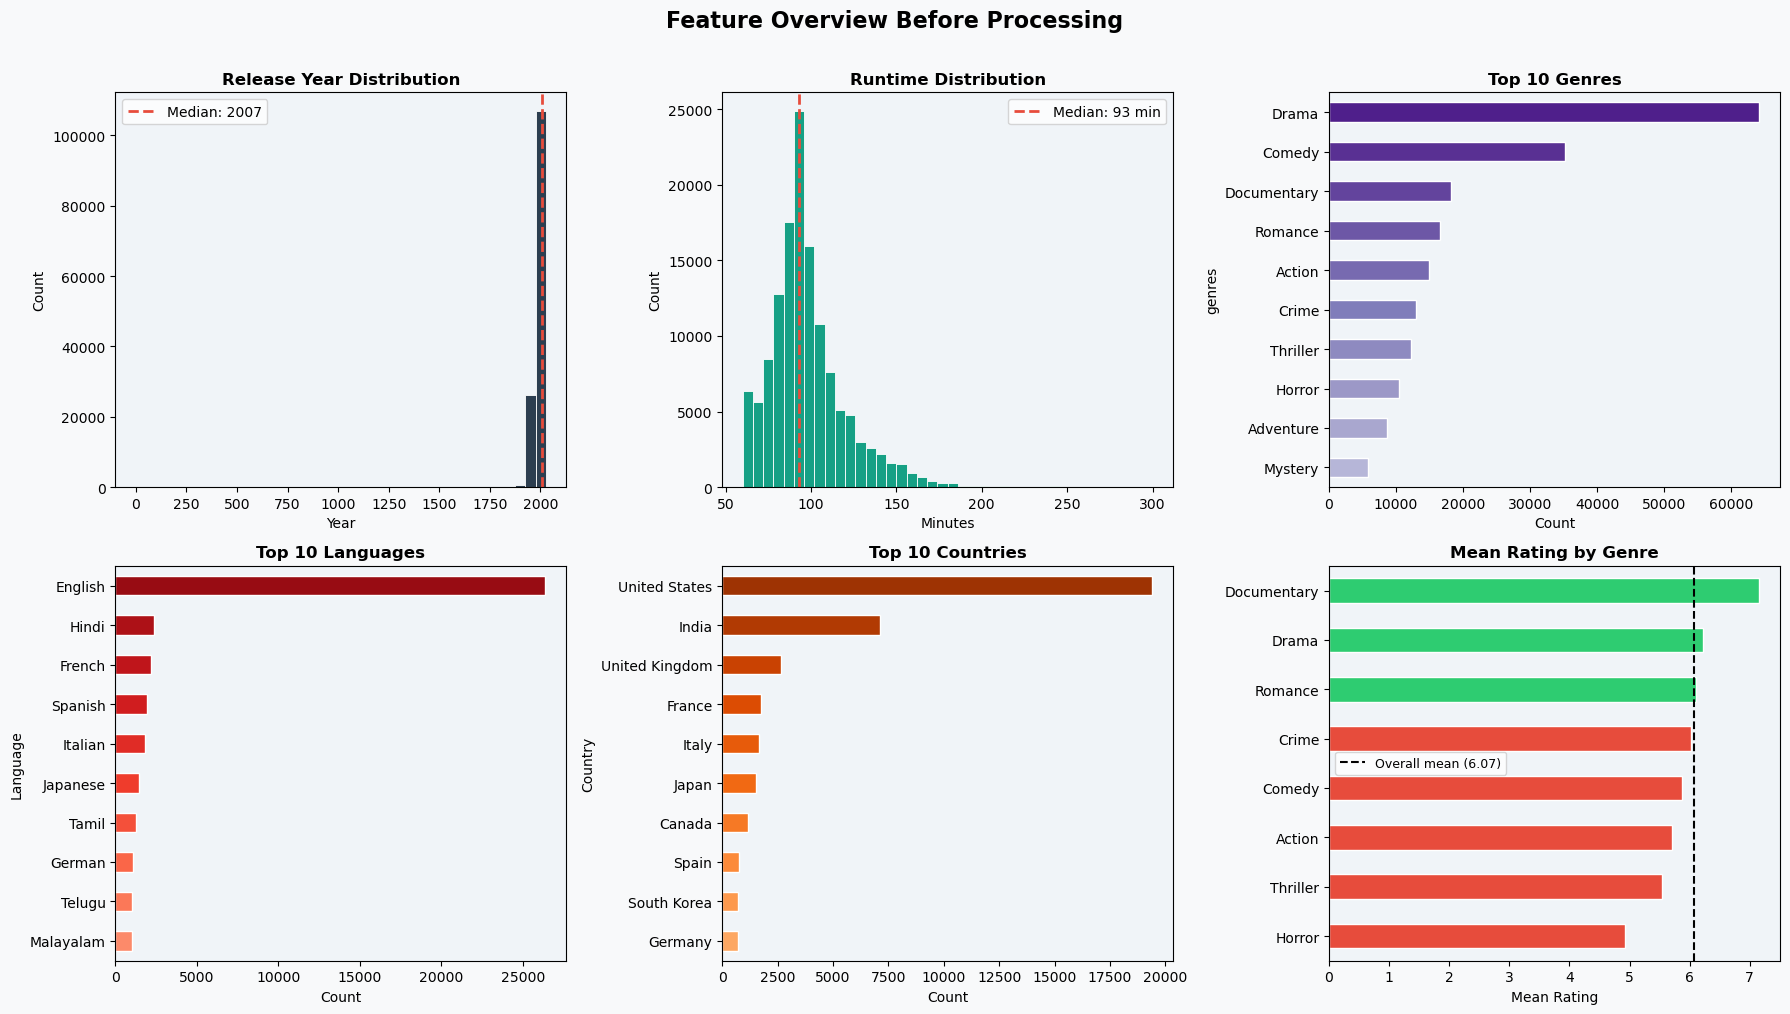

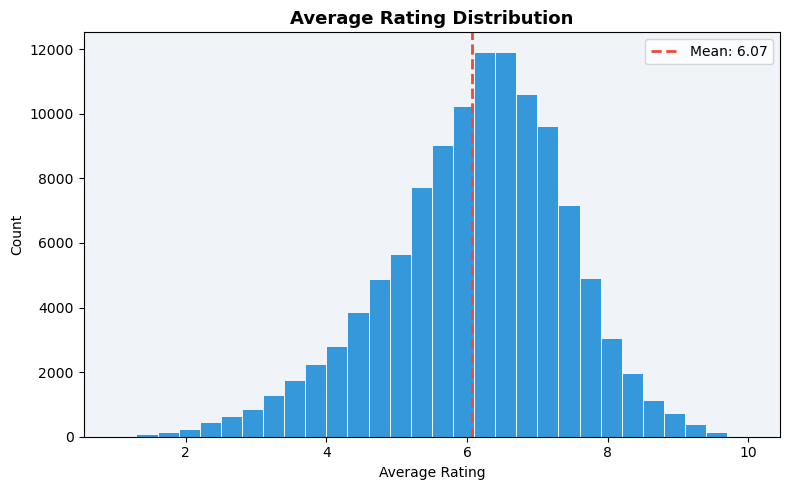

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#f8f9fa')

# 1. startYear
ax = axes[0, 0]
ax.set_facecolor('#f0f4f8')
years = df['startYear'].dropna().astype(float)
ax.hist(years, bins=40, color='#2c3e50', edgecolor='white', linewidth=0.6)
ax.set_title('Release Year Distribution', fontweight='bold', fontsize=12)
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.axvline(years.median(), color='#e74c3c', lw=2, linestyle='--',
           label=f'Median: {int(years.median())}')
ax.legend()

# 2. runtimeMinutes
ax = axes[0, 1]
ax.set_facecolor('#f0f4f8')
runtime = df['runtimeMinutes'].dropna().astype(float)
runtime = runtime[runtime <= 300]
ax.hist(runtime, bins=40, color='#16a085', edgecolor='white', linewidth=0.6)
ax.set_title('Runtime Distribution', fontweight='bold', fontsize=12)
ax.set_xlabel('Minutes')
ax.set_ylabel('Count')
ax.axvline(runtime.median(), color='#e74c3c', lw=2, linestyle='--',
           label=f'Median: {int(runtime.median())} min')
ax.legend()

# 3. genres
ax = axes[0, 2]
ax.set_facecolor('#f0f4f8')
all_genres = df['genres'].dropna().str.split(',').explode().str.strip()
all_genres = all_genres.str.replace(r"[\[\]'\"]", "", regex=True).str.strip()
all_genres = all_genres[all_genres != '']
top_genres = all_genres.value_counts().head(10)
colors_g = plt.cm.Purples(np.linspace(0.4, 0.9, len(top_genres)))[::-1]
top_genres.plot(kind='barh', ax=ax, color=colors_g, edgecolor='white')
ax.set_title('Top 10 Genres', fontweight='bold', fontsize=12)
ax.set_xlabel('Count')
ax.invert_yaxis()

# 4. Language
ax = axes[1, 0]
ax.set_facecolor('#f0f4f8')
langs = df['Language'][df['Language'] != 'Not Found'].value_counts().head(10)
colors_l = plt.cm.Reds(np.linspace(0.4, 0.9, len(langs)))[::-1]
langs.plot(kind='barh', ax=ax, color=colors_l, edgecolor='white')
ax.set_title('Top 10 Languages', fontweight='bold', fontsize=12)
ax.set_xlabel('Count')
ax.invert_yaxis()

# 5. Country
ax = axes[1, 1]
ax.set_facecolor('#f0f4f8')
countries = df['Country'][df['Country'] != 'Not Found'].value_counts().head(10)
colors_c = plt.cm.Oranges(np.linspace(0.4, 0.9, len(countries)))[::-1]
countries.plot(kind='barh', ax=ax, color=colors_c, edgecolor='white')
ax.set_title('Top 10 Countries', fontweight='bold', fontsize=12)
ax.set_xlabel('Count')
ax.invert_yaxis()

# 6. Mean Rating by Genre
ax = axes[1, 2]
ax.set_facecolor('#f0f4f8')

df_rated = df[df['averageRating'].notna()]
genre_means = {}

for g in ['Documentary', 'Drama', 'Romance', 'Crime',
          'Comedy', 'Action', 'Thriller', 'Horror']:
    mask = df_rated['genres'].fillna('').str.contains(g)
    if mask.sum() > 100:
        genre_means[g] = df_rated.loc[mask, 'averageRating'].mean()

genre_series = pd.Series(genre_means).sort_values(ascending=True)
overall_mean = df_rated['averageRating'].mean()

colors_r = ['#e74c3c' if v < overall_mean else '#2ecc71'
            for v in genre_series.values]

genre_series.plot(kind='barh', ax=ax, color=colors_r, edgecolor='white')
ax.axvline(overall_mean, color='black', lw=1.5, linestyle='--',
           label=f'Overall mean ({overall_mean:.2f})')
ax.set_title('Mean Rating by Genre', fontweight='bold', fontsize=12)
ax.set_xlabel('Mean Rating')
ax.legend(fontsize=9)

plt.suptitle('Feature Overview Before Processing',
             fontsize=16, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()


# 7. Average Rating Distribution
plt.figure(figsize=(8, 5))
plt.gca().set_facecolor('#f0f4f8')

ratings = df['averageRating'].dropna()

plt.hist(ratings, bins=30, color='#3498db',
         edgecolor='white', linewidth=0.6)

plt.axvline(ratings.mean(), color='#e74c3c',
            lw=2, linestyle='--',
            label=f'Mean: {ratings.mean():.2f}')

plt.title('Average Rating Distribution',
          fontweight='bold', fontsize=13)

plt.xlabel('Average Rating')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

<div dir="rtl">

## יצירת הפונקציה prepare data ונקיון


In [13]:
import pandas as pd
import numpy as np
import ast

def prepare_data(df):
    data = df.copy()

    # ===================================
    # Step 1: Remove leakage columns
    # ===================================
    # numVotes, BoxOffice — post-release data
    # averageRating — target variable
    # tconst — technical ID
    leakage_cols = ['tconst', 'numVotes', 'BoxOffice', 'averageRating']
    data = data.drop(
        columns=[c for c in leakage_cols if c in data.columns],
        errors='ignore'
    )

    # ===================================
    # Step 2: Clean numeric columns
    # ===================================
    if 'startYear' in data.columns:
        data['startYear'] = pd.to_numeric(data['startYear'], errors='coerce')
        data.loc[~data['startYear'].between(1900, 2025), 'startYear'] = np.nan

    if 'runtimeMinutes' in data.columns:
        data['runtimeMinutes'] = pd.to_numeric(data['runtimeMinutes'], errors='coerce')
        data.loc[~data['runtimeMinutes'].between(1, 500), 'runtimeMinutes'] = np.nan

    if 'budget' in data.columns:
        data['budget'] = pd.to_numeric(data['budget'], errors='coerce')
        data.loc[~data['budget'].between(1, 1_000_000_000), 'budget'] = np.nan

    # ===================================
    # Step 3: Clean genres
    # ===================================
    if 'genres' in data.columns:
        def clean_genres(x):
            if pd.isna(x):
                return np.nan
            x = str(x).strip()
            # Format 1: ['Drama','Comedy']
            if x.startswith('['):
                try:
                    parsed = ast.literal_eval(x)
                    if isinstance(parsed, list):
                        return ','.join(sorted(parsed))
                except:
                    pass
            # Format 2: Drama,Comedy
            cleaned = x.replace("'", "").replace('"', "").strip()
            if cleaned in ['\\N', 'None', 'nan', 'Not Found', '']:
                return np.nan
            return cleaned

        data['genres'] = data['genres'].apply(clean_genres)

    # ===================================
    # Step 4: Clean Language
    # ===================================
    # We search the full text — a film can have multiple languages
    if 'Language' in data.columns:
        data['Language'] = data['Language'].astype(str).str.strip()
        data['Language'] = data['Language'].replace(
            ['\\N', 'None', 'nan', 'Not Found', 'N', 'none'], np.nan
        )

    # ===================================
    # Step 5: Clean Country
    # ===================================
    # We search the full text — a film can have multiple countries
    if 'Country' in data.columns:
        data['Country'] = data['Country'].astype(str).str.strip()
        data['Country'] = data['Country'].str.replace(
            r"[\[\]'\n]", '', regex=True
        )
        data['Country'] = data['Country'].replace(
            ['\\N', 'None', 'nan', 'Not Found', 'N',
             'Earth', 'International', 'none'], np.nan
        )

    # ===================================
    # Step 6: Feature Engineering
    # ===================================

    # 1. movie_age
    # Older films tend to have higher ratings — Survivorship Bias
    # Only the good ones survived and are still rated
    if 'startYear' in data.columns:
        data['movie_age'] = 2025 - data['startYear']

    # 2. num_genres
    # Niche film (1 genre) vs. commercial (2-3 genres)
    if 'genres' in data.columns:
        data['num_genres'] = data['genres'].apply(
            lambda x: len(str(x).split(',')) if pd.notna(x) else np.nan
        )

    # 3. runtime_category
    # Most films are 80-120 min — binning captures this pattern
    if 'runtimeMinutes' in data.columns:
        data['runtime_category'] = pd.cut(
            data['runtimeMinutes'],
            bins=[0, 90, 120, np.inf],
            labels=['short', 'medium', 'long']
        )

    # 4. is_english
    # Searches full text — film can have multiple languages
    # EDA showed English is dominant by a large margin
    if 'Language' in data.columns:
        data['is_english'] = data['Language'].apply(
            lambda x: 1 if pd.notna(x) and 'English' in str(x) else 0
        )

    # 5. runtime_per_genre — Complex feature (ratio)
    # Long film with 1 genre = niche = high rating
    # Short film with many genres = commercial = average rating
    if 'runtimeMinutes' in data.columns and 'num_genres' in data.columns:
        data['runtime_per_genre'] = (
            data['runtimeMinutes'] / data['num_genres'].replace(0, np.nan)
        )

    # 6. Country binary flags
    # Searches full text — film can have multiple countries
    # EDA showed USA dominant, India second, Europe and East Asia present
    if 'Country' in data.columns:
        data['is_usa'] = data['Country'].apply(
            lambda x: 1 if pd.notna(x) and
            any(c in str(x) for c in ['United States', 'USA', 'U.S.'])
            else 0
        )
        # Europe without UK — to avoid overlap with is_english
        data['is_europe'] = data['Country'].apply(
            lambda x: 1 if pd.notna(x) and
            any(c in str(x) for c in ['France', 'Germany', 'Italy', 'Spain'])
            else 0
        )
        data['is_india'] = data['Country'].apply(
            lambda x: 1 if pd.notna(x) and 'India' in str(x) else 0
        )
        data['is_east_asian'] = data['Country'].apply(
            lambda x: 1 if pd.notna(x) and
            any(c in str(x) for c in ['Japan', 'South Korea', 'China'])
            else 0
        )

    # 7. Genre binary flags
    # Each film can belong to multiple genres — binary flags not OHE
    # EDA showed significant rating differences between genres
    top_genres = [
        'Drama', 'Comedy', 'Documentary', 'Horror',
        'Action', 'Romance', 'Thriller', 'Crime'
    ]
    for genre in top_genres:
        if 'genres' in data.columns:
            data[f'genre_{genre}'] = data['genres'].apply(
                lambda x: 1 if pd.notna(x) and genre in str(x) else 0
            )
        else:
            data[f'genre_{genre}'] = 0

    # ===================================
    # Step 7: Drop columns no longer needed
    # ===================================
    cols_to_remove = [
        'primaryTitle',    # film title — not a feature
        'plot',            # free text
        'lead_actors_ids', # too complex to process
        'genres',          # replaced by genre flags + num_genres
        'startYear',       # replaced by movie_age
        'budget',          # 87% missing
        'Language',        # replaced by is_english
        'Country'          # replaced by is_usa, is_europe, is_india, is_east_asian
    ]
    data = data.drop(
        columns=[c for c in cols_to_remove if c in data.columns],
        errors='ignore'
    )

    # runtime_category stays — Pipeline handles it with OHE

    return data

In [14]:
X_sample = prepare_data(df.head(5))
print(f'סה"כ עמודות: {X_sample.shape[1]}')
print('\nרשימת עמודות:')
for col in X_sample.columns:
    print(f'  {col}')

סה"כ עמודות: 18

רשימת עמודות:
  runtimeMinutes
  movie_age
  num_genres
  runtime_category
  is_english
  runtime_per_genre
  is_usa
  is_europe
  is_india
  is_east_asian
  genre_Drama
  genre_Comedy
  genre_Documentary
  genre_Horror
  genre_Action
  genre_Romance
  genre_Thriller
  genre_Crime


<div dir="rtl">

### טבלת פיצ'רים וכל הדאטה

In [16]:
feature_table = pd.DataFrame([
    {
        'פיצ׳ר': 'movie_age',
        'נוסחה': '2025 - startYear',
        'סוג': 'נומרי'
    },
    {
        'פיצ׳ר': 'num_genres',
        'נוסחה': 'מספר הז׳אנרים',
        'סוג': 'נומרי'
    },
    {
        'פיצ׳ר': 'runtime_category',
        'נוסחה': 'קצר / בינוני / ארוך',
        'סוג': 'קטגוריאלי'
    },
    {
        'פיצ׳ר': 'is_english',
        'נוסחה': '1 אם הסרט כולל אנגלית',
        'סוג': 'בינארי'
    },
    {
        'פיצ׳ר': 'runtime_per_genre',
        'נוסחה': 'runtimeMinutes / num_genres',
        'סוג': 'נומרי מורכב'
    },
    {
        'פיצ׳ר': 'is_usa',
        'נוסחה': '1 אם הסרט מארה״ב',
        'סוג': 'בינארי'
    },
    {
        'פיצ׳ר': 'is_europe',
        'נוסחה': '1 אם הסרט מצרפת/גרמניה/איטליה/ספרד',
        'סוג': 'בינארי'
    },
    {
        'פיצ׳ר': 'is_india',
        'נוסחה': '1 אם הסרט מהודו',
        'סוג': 'בינארי'
    },
    {
        'פיצ׳ר': 'is_east_asian',
        'נוסחה': '1 אם הסרט מיפן, סין או דרום קוריאה',
        'סוג': 'בינארי'
    },
    {
        'פיצ׳ר': 'genre_*',
        'נוסחה': '1 אם הסרט שייך לז׳אנר',
        'סוג': 'בינארי'
    },
])

display(
    feature_table.style
    .set_caption('טבלת הפיצ׳רים שנוצרו בתהליך Feature Engineering')
    .set_table_styles([{
        'selector': 'th',
        'props': [
            ('background-color', '#2c3e50'),
            ('color', 'white'),
            ('font-weight', 'bold')
        ]
    }])
    .apply(
        lambda col: [
            'background-color: #d5f5e3' if v == 'נומרי מורכב'
            else 'background-color: #d6eaf8' if v == 'נומרי'
            else 'background-color: #fdebd0' if v == 'בינארי'
            else 'background-color: #f9ebea'
            for v in col
        ],
        subset=['סוג']
    )
    .hide(axis='index')
)

פיצ׳ר,נוסחה,סוג
movie_age,2025 - startYear,נומרי
num_genres,מספר הז׳אנרים,נומרי
runtime_category,קצר / בינוני / ארוך,קטגוריאלי
is_english,1 אם הסרט כולל אנגלית,בינארי
runtime_per_genre,runtimeMinutes / num_genres,נומרי מורכב
is_usa,1 אם הסרט מארה״ב,בינארי
is_europe,1 אם הסרט מצרפת/גרמניה/איטליה/ספרד,בינארי
is_india,1 אם הסרט מהודו,בינארי
is_east_asian,"1 אם הסרט מיפן, סין או דרום קוריאה",בינארי
genre_*,1 אם הסרט שייך לז׳אנר,בינארי


In [17]:
X_sample = prepare_data(df.head(5))
print(f"גודל: {X_sample.shape}")
print(f"\nעמודות:")
print(X_sample.columns.tolist())
X_sample.head()

גודל: (5, 18)

עמודות:
['runtimeMinutes', 'movie_age', 'num_genres', 'runtime_category', 'is_english', 'runtime_per_genre', 'is_usa', 'is_europe', 'is_india', 'is_east_asian', 'genre_Drama', 'genre_Comedy', 'genre_Documentary', 'genre_Horror', 'genre_Action', 'genre_Romance', 'genre_Thriller', 'genre_Crime']


,runtimeMinutes,movie_age,num_genres,runtime_category,is_english,runtime_per_genre,is_usa,is_europe,is_india,is_east_asian,genre_Drama,genre_Comedy,genre_Documentary,genre_Horror,genre_Action,genre_Romance,genre_Thriller,genre_Crime
0,90.0,32.0,3,short,0,30.0,0,0,0,0,1,0,0,0,0,0,1,1
1,86.0,1.0,1,short,0,86.0,0,0,0,0,1,0,0,0,0,0,0,0
2,90.0,1.0,2,short,0,45.0,0,0,0,0,1,0,0,0,0,1,0,0
3,60.0,32.0,1,short,0,60.0,0,0,0,0,0,0,1,0,0,0,0,0
4,102.0,19.0,1,medium,0,102.0,0,0,0,0,0,1,0,0,0,0,0,0


<div dir="rtl">

## חלוקה ל-train/test והפעלת prepare_data

חשוב: מחלקים קודם, ואז מפעילים את prepare_data על כל חלק בנפרד כדי למנוע Data Leakage!


In [19]:
df_clean = df[df['averageRating'].notna()].copy()
y = df_clean['averageRating']
X = df_clean.drop(columns=['averageRating'])


X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

X_train = prepare_data(X_train_raw)
X_test = prepare_data(X_test_raw)

print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test: {y_test.shape}')


X_train: (92448, 18)
X_test: (23112, 18)
y_train: (92448,)
y_test: (23112,)


In [20]:
print(X_train.columns.tolist())

['runtimeMinutes', 'movie_age', 'num_genres', 'runtime_category', 'is_english', 'runtime_per_genre', 'is_usa', 'is_europe', 'is_india', 'is_east_asian', 'genre_Drama', 'genre_Comedy', 'genre_Documentary', 'genre_Horror', 'genre_Action', 'genre_Romance', 'genre_Thriller', 'genre_Crime']


In [21]:
X_train.shape

(92448, 18)

<div dir="rtl">

## הגדרת עמודות ו-Pipeline


In [23]:
# עמודות נומריות — יעברו imputation + scaling
numerical_cols = [
    'runtimeMinutes',      # אורך הסרט בדקות
    'movie_age',           # גיל הסרט (2025 - startYear)
    'num_genres',          # כמה ז'אנרים יש לסרט
    'runtime_per_genre'    # פיצ'ר מורכב: אורך / ז'אנרים
]

# עמודות בינאריות — יעברו רק imputation
binary_cols = [
    'is_english',          # 1 אם English בשפות הסרט
    'is_usa',              # 1 אם United States במדינות הסרט
    'is_europe',           # 1 אם France/Germany/Italy/Spain במדינות
    'is_india',            # 1 אם India במדינות הסרט
    'is_east_asian',       # 1 אם Japan/South Korea/China במדינות
    'genre_Drama',         # 1 אם הסרט דרמה
    'genre_Comedy',        # 1 אם הסרט קומדיה
    'genre_Documentary',   # 1 אם הסרט דוקומנטרי
    'genre_Horror',        # 1 אם הסרט אימה
    'genre_Action',        # 1 אם הסרט אקשן
    'genre_Romance',       # 1 אם הסרט רומנטי
    'genre_Thriller',      # 1 אם הסרט מתח
    'genre_Crime'          # 1 אם הסרט פשע
]

# עמודות קטגוריאליות — יעברו imputation + OHE
categorical_cols = [
    'runtime_category'     # short / medium / long
]

# Pipeline לעמודות נומריות
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Pipeline לעמודות בינאריות
binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0))
])

# Pipeline לעמודות קטגוריאליות
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Other')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numerical_cols),
    ('bin', binary_pipeline, binary_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

print('Preprocessor defined')
print(f'  Numeric     : {len(numerical_cols)} columns → imputer(median) + scaler')
print(f'  Binary      : {len(binary_cols)} columns → imputer(0)')
print(f'  Categorical : {len(categorical_cols)} columns → imputer(Other) + OHE')

Preprocessor defined
  Numeric     : 4 columns → imputer(median) + scaler
  Binary      : 13 columns → imputer(0)
  Categorical : 1 columns → imputer(Other) + OHE


In [24]:
print(X_train.shape)
print(X_train.columns.tolist())

(92448, 18)
['runtimeMinutes', 'movie_age', 'num_genres', 'runtime_category', 'is_english', 'runtime_per_genre', 'is_usa', 'is_europe', 'is_india', 'is_east_asian', 'genre_Drama', 'genre_Comedy', 'genre_Documentary', 'genre_Horror', 'genre_Action', 'genre_Romance', 'genre_Thriller', 'genre_Crime']


<div dir="rtl">

## 3.2 מודל 1 - ElasticNet


In [26]:
elasticnet_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ElasticNet(random_state=RANDOM_STATE, max_iter=10000))
])

param_grid_en = {
    'model__alpha'   : [0.0005, 0.005, 0.05, 0.3, 0.8],
    'model__l1_ratio': [0.15, 0.35, 0.55, 0.75, 1.0]
}

kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

grid_search_en = GridSearchCV(
    elasticnet_pipeline,
    param_grid_en,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid_search_en.fit(X_train, y_train)

best_en = grid_search_en.best_estimator_

print(f'Best alpha    : {grid_search_en.best_params_["model__alpha"]}')
print(f'Best l1_ratio : {grid_search_en.best_params_["model__l1_ratio"]}')
print(f'Best CV RMSE  : {-grid_search_en.best_score_:.4f}')

Fitting 10 folds for each of 25 candidates, totalling 250 fits
Best alpha    : 0.0005
Best l1_ratio : 0.15
Best CV RMSE  : 1.1392


<div dir="rtl">

## 3.3 הערכת ElasticNet עם 10-fold CV


In [28]:
final_elasticnet = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ElasticNet(
        alpha=grid_search_en.best_params_['model__alpha'],
        l1_ratio=grid_search_en.best_params_['model__l1_ratio'],
        random_state=RANDOM_STATE,
        max_iter=10000
    ))
])

kf_final = KFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results_en = cross_validate(
    final_elasticnet,
    X_train,
    y_train,
    cv=kf_final,
    scoring=[
        'neg_root_mean_squared_error',
        'neg_mean_absolute_error',
        'r2'
    ],
    return_train_score=False,
    n_jobs=-1
)

print('תוצאות ElasticNet עם 10-fold CV:')
print(f"RMSE: {-cv_results_en['test_neg_root_mean_squared_error'].mean():.4f} ± {cv_results_en['test_neg_root_mean_squared_error'].std():.4f}")
print(f"MAE:  {-cv_results_en['test_neg_mean_absolute_error'].mean():.4f} ± {cv_results_en['test_neg_mean_absolute_error'].std():.4f}")
print(f"R²:   {cv_results_en['test_r2'].mean():.4f} ± {cv_results_en['test_r2'].std():.4f}")

best_en = final_elasticnet
best_en.fit(X_train, y_train)
print('✅ ElasticNet אומן על כל ה-train')

תוצאות ElasticNet עם 10-fold CV:
RMSE: 1.1392 ± 0.0139
MAE:  0.8735 ± 0.0091
R²:   0.2252 ± 0.0063
✅ ElasticNet אומן על כל ה-train


<div dir="rtl">

## מודל 2 - Random Forest


In [30]:
from sklearn.model_selection import RandomizedSearchCV

# שלב 1: RandomizedSearchCV — מציאת פרמטרים טובים
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

param_grid_rf = {
    'model__n_estimators'    : [100, 200, 300],
    'model__max_depth'       : [10, 20, None],
    'model__min_samples_leaf': [3, 5, 10],
    'model__max_features'    : ['sqrt', 0.5]
}

rf_random_search = RandomizedSearchCV(
    rf_pipeline,
    param_grid_rf,
    n_iter=8,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

rf_random_search.fit(X_train, y_train)

print(f'Best params: {rf_random_search.best_params_}')
print(f'Best RMSE  : {-rf_random_search.best_score_:.4f}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'model__n_estimators': 300, 'model__min_samples_leaf': 10, 'model__max_features': 'sqrt', 'model__max_depth': None}
Best RMSE  : 1.1122


In [31]:
# שלב 2: 10-fold CV סופי עם הפרמטרים הטובים
best_rf = rf_random_search.best_estimator_

kf_final = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

cv_results_rf = cross_validate(
    best_rf,
    X_train,
    y_train,
    cv=kf_final,
    scoring=[
        'neg_root_mean_squared_error',
        'neg_mean_absolute_error',
        'r2'
    ],
    return_train_score=False,
    n_jobs=-1
)

print('Random Forest — 10-fold CV Results:')
print(f"RMSE: {-cv_results_rf['test_neg_root_mean_squared_error'].mean():.4f} ± {cv_results_rf['test_neg_root_mean_squared_error'].std():.4f}")
print(f"MAE:  {-cv_results_rf['test_neg_mean_absolute_error'].mean():.4f} ± {cv_results_rf['test_neg_mean_absolute_error'].std():.4f}")
print(f"R²:   {cv_results_rf['test_r2'].mean():.4f} ± {cv_results_rf['test_r2'].std():.4f}")

Random Forest — 10-fold CV Results:
RMSE: 1.1115 ± 0.0157
MAE:  0.8481 ± 0.0096
R²:   0.2624 ± 0.0084


<div dir="rtl">

## השוואת מודלים


In [33]:
comparison = pd.DataFrame([
    {
        'Model': 'ElasticNet',
        'RMSE': -cv_results_en['test_neg_root_mean_squared_error'].mean(),
        'MAE' : -cv_results_en['test_neg_mean_absolute_error'].mean(),
        'R²'  : cv_results_en['test_r2'].mean()
    },
    {
        'Model': 'Random Forest',
        'RMSE': -cv_results_rf['test_neg_root_mean_squared_error'].mean(),
        'MAE' : -cv_results_rf['test_neg_mean_absolute_error'].mean(),
        'R²'  : cv_results_rf['test_r2'].mean()
    }
])

comparison.style \
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R²': '{:.4f}'}) \
    .background_gradient(subset=['RMSE', 'MAE'], cmap='RdYlGn_r') \
    .background_gradient(subset=['R²'], cmap='RdYlGn') \
    .set_caption('Model Comparison — 10-Fold CV') \
    .hide(axis='index')

Model,RMSE,MAE,R²
ElasticNet,1.1392,0.8735,0.2252
Random Forest,1.1115,0.8481,0.2624


<div dir="rtl">

### גרף השוואה בין המודלים

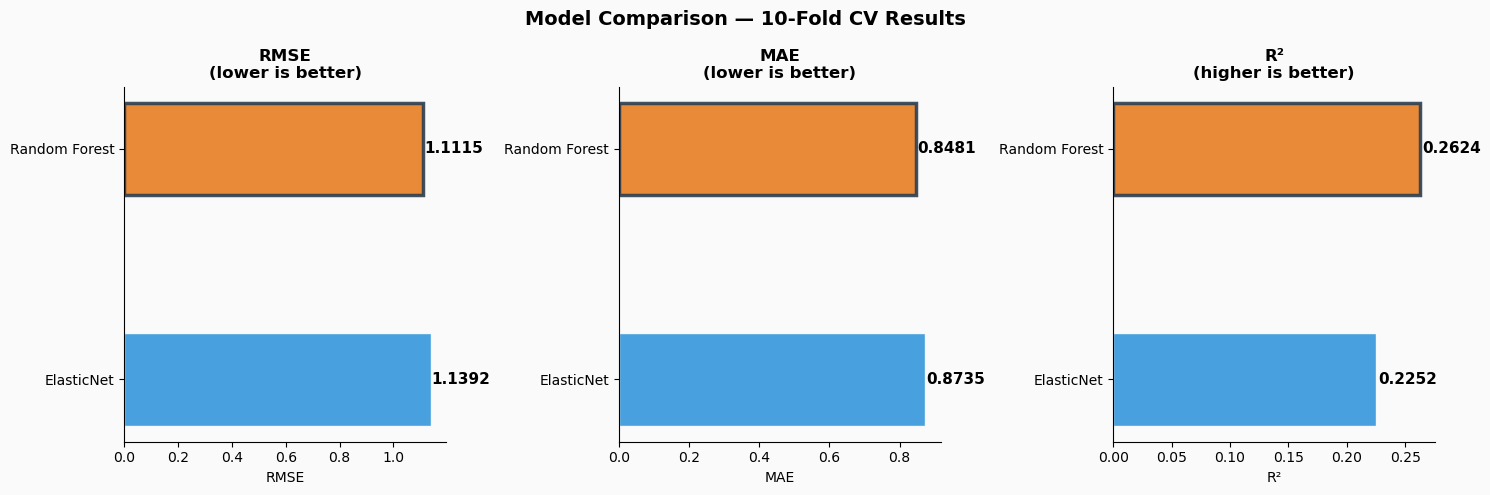

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('#fafafa')

metrics = [
    ('RMSE', 'lower is better', True),
    ('MAE',  'lower is better', True),
    ('R²',   'higher is better', False)
]

bar_colors = ['#3498db', '#e67e22']  # כחול ל-ElasticNet, כתום ל-RF

for ax, (metric, note, lower_better) in zip(axes, metrics):
    values = comparison[metric].values
    models = comparison['Model'].values

    bars = ax.barh(models, values,
                   color=bar_colors,
                   edgecolor='white',
                   height=0.4,
                   alpha=0.9)

    # ערך בתוך או ליד העמודה
    for bar, val in zip(bars, values):
        ax.text(val + 0.002,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}',
                va='center', fontsize=11, fontweight='bold')

    # הדגשת הטוב יותר
    best_idx = values.argmin() if lower_better else values.argmax()
    bars[best_idx].set_edgecolor('#2c3e50')
    bars[best_idx].set_linewidth(2.5)

    ax.set_title(f'{metric}\n({note})', fontweight='bold', fontsize=12)
    ax.set_xlabel(metric)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_facecolor('#fafafa')

plt.suptitle('Model Comparison — 10-Fold CV Results',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<div dir="rtl">

## ניתוח שגיאות-ERROR ANALYSIS

In [37]:
# ===========================
# Error Analysis — תא אחד מלא
# ===========================

# שלב 1 — תחזיות OOF
y_pred_rf_oof = cross_val_predict(
    best_rf, X_train, y_train, cv=kf, n_jobs=-1
)
y_pred_en_oof = cross_val_predict(
    best_en, X_train, y_train, cv=kf, n_jobs=-1
)

# שלב 2 — טבלת שגיאות
errors_df = pd.DataFrame({
    'primaryTitle' : df.loc[X_train.index, 'primaryTitle'].values,
    'startYear'    : df.loc[X_train.index, 'startYear'].values,
    'genres'       : df.loc[X_train.index, 'genres'].values,
    'actual'       : y_train.values,
    'predicted_rf' : y_pred_rf_oof.round(2),
    'predicted_en' : y_pred_en_oof.round(2),
    'error_rf'     : (y_pred_rf_oof - y_train.values).round(2),
    'error_en'     : (y_pred_en_oof - y_train.values).round(2),
}).reset_index(drop=True)

# שלב 3 — חילוץ outliers
top_over  = errors_df.nlargest(10, 'error_rf')
top_under = errors_df.nsmallest(10, 'error_rf')

# שלב 4 — הצגה
print('TOP 10 Overpredictions:')
display(top_over[['primaryTitle', 'startYear', 'genres', 'actual', 'predicted_rf', 'error_rf']])

print('\nTOP 10 Underpredictions:')
display(top_under[['primaryTitle', 'startYear', 'genres', 'actual', 'predicted_rf', 'error_rf']])

TOP 10 Overpredictions:


,primaryTitle,startYear,genres,actual,predicted_rf,error_rf
37840,Kurz,2023.0,Documentary,1.2,7.14,5.94
28147,At the Back of the Screen,2020.0,"Documentary,Drama",1.5,7.37,5.87
37480,Tribalism Is Killing Us,2019.0,['Documentary'],1.3,7.10,5.80
77542,Obama in NC: The Path to History,2010.0,['Documentary'],1.5,7.18,5.68
25616,Play in the Gray,2009.0,"Biography,Comedy,Documentary",1.3,6.92,5.62
2061,Brush with Life: The Art of Being Edward Biberman,2007.0,['Documentary'],1.5,7.11,5.61
12871,Justin Bieber's Believe,2013.0,"Documentary,Music",1.6,7.19,5.59
87288,Hatemongers,2000.0,Documentary,1.6,7.16,5.56
8029,Justin Bieber: Never Say Never,2011.0,"Documentary,Music",1.7,7.25,5.55
71778,Proud American,2008.0,Drama,1.1,6.55,5.45



TOP 10 Underpredictions:


,primaryTitle,startYear,genres,actual,predicted_rf,error_rf
78965,Bukunja Tekunja Mitti: The Cannibals,2012.0,"['Action', 'Horror']",9.1,4.13,-4.97
31661,Son-nim-1 Cheo-beon-jjae I-ya-gi,2011.0,"Horror,Thriller",9.1,4.42,-4.68
41980,Of Sound Mind,2015.0,"['Romance', 'Thriller']",9.6,5.15,-4.45
65781,Oscuro by Rene Potter,2016.0,['Horror'],8.6,4.22,-4.38
76416,Hell Squad 2: Fresh Meat,2024.0,Horror,8.9,4.62,-4.28
42724,Il Santo Veleno,2023.0,Thriller,9.4,5.13,-4.27
5258,Afterthought,2016.0,"['Drama', 'Horror', 'Thriller']",9.0,4.76,-4.24
81027,Justicia Implacable,2023.0,"Action,Drama,Horror",9.5,5.28,-4.22
4561,Pulse of the Indigo,2012.0,"Crime,Thriller",9.3,5.13,-4.17
5706,Avengers: Doom of the World,2023.0,"Action,Adventure",8.9,4.73,-4.17


<div dir="rtl">

## 5.2 ניתוח איכותי

### Overpredictions
כל 10 הסרטים הם דוקומנטרים עם דירוג אמיתי של 1.1–1.7.
המודל חזה ~7 כי למד ש-Documentary = דירוג גבוה.
הסיבה לשגיאה: vote bombing — קהל עוין דירג 1/10 בכוונה לאחר יציאת הסרט.
מה המודל לא יכול לדעת: זהות הקהל ומניעיו — מידע שלא קיים לפני יציאה.

### Underpredictions
כל 10 הסרטים מדורגים 8.6–9.6 אבל המודל חזה ~4.5.
רובם Horror או Thriller — ז'אנרים שהמודל למד שמדורגים נמוך.
הסיבה לשגיאה: קהל נישה קטן ונלהב שדירג 10/10 — לא מייצג.
מה המודל לא יכול לדעת: קיומו של קהל מעריצים ספציפי לפני יציאה.

### מסקנה
שתי קבוצות השגיאות נובעות מאותה סיבה — קהל לא מייצג.
זו מגבלה מובנית: הדירוג ב-IMDb לא תמיד משקף איכות הסרט,
אלא גם פוליטיקה של דירוגים שלא ניתן לחזות לפני יציאה.

</div>

<div dir="rtl">

## 5.3 השוואה בין מודלים


In [40]:
# חישוב outliers
outliers_rf  = set(top_over.index)  | set(top_under.index)
top_over_en  = errors_df.nlargest(10,  'error_en')
top_under_en = errors_df.nsmallest(10, 'error_en')
outliers_en  = set(top_over_en.index) | set(top_under_en.index)

overlap = outliers_rf & outliers_en
only_rf = outliers_rf - outliers_en
only_en = outliers_en - outliers_rf

print(f'חפיפה: {len(overlap)}/20 ({len(overlap)/20*100:.0f}%)')
print(f'רק RF: {len(only_rf)}')
print(f'רק EN: {len(only_en)}')

חפיפה: 13/20 (65%)
רק RF: 7
רק EN: 7


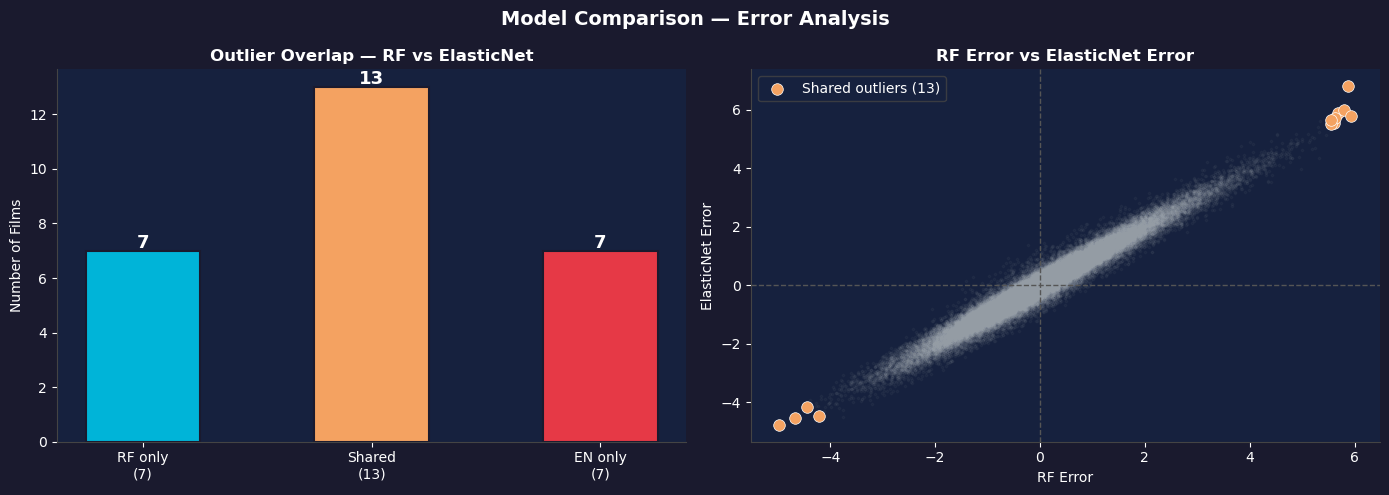

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#1a1a2e')

# גרף 1 — bar chart
ax = axes[0]
ax.set_facecolor('#16213e')

sizes  = [len(only_rf), len(overlap), len(only_en)]
labels = [f'RF only\n({len(only_rf)})',
          f'Shared\n({len(overlap)})',
          f'EN only\n({len(only_en)})']
colors = ['#00b4d8', '#f4a261', '#e63946']

bars = ax.bar(labels, sizes, color=colors,
              edgecolor='#1a1a2e', linewidth=1.5,
              width=0.5)

for bar, size in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            str(size), ha='center',
            fontweight='bold', fontsize=13, color='white')

ax.set_title('Outlier Overlap — RF vs ElasticNet',
             fontweight='bold', color='white')
ax.set_ylabel('Number of Films', color='white')
ax.tick_params(colors='white')
ax.set_facecolor('#16213e')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#444')
ax.spines['bottom'].set_color('#444')

# גרף 2 — scatter
ax = axes[1]
ax.set_facecolor('#16213e')

ax.scatter(errors_df['error_rf'], errors_df['error_en'],
           alpha=0.04, s=3, color='#adb5bd')
ax.axhline(0, color='#555', lw=1, linestyle='--')
ax.axvline(0, color='#555', lw=1, linestyle='--')

shared_idx = list(overlap)
ax.scatter(errors_df.loc[shared_idx, 'error_rf'],
           errors_df.loc[shared_idx, 'error_en'],
           color='#f4a261', s=70, zorder=5,
           edgecolor='white', linewidth=0.5,
           label=f'Shared outliers ({len(overlap)})')

ax.set_xlabel('RF Error', color='white')
ax.set_ylabel('ElasticNet Error', color='white')
ax.set_title('RF Error vs ElasticNet Error',
             fontweight='bold', color='white')
ax.tick_params(colors='white')
ax.legend(facecolor='#16213e', labelcolor='white',
          edgecolor='#444')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#444')
ax.spines['bottom'].set_color('#444')

plt.suptitle('Model Comparison — Error Analysis',
             fontsize=14, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

In [42]:
# סרטים ייחודיים ל-RF
rf_unique = list(only_rf)
print("ייחודיים ל-RF:")
display(errors_df.loc[rf_unique, ['primaryTitle', 'genres', 'actual', 'predicted_rf', 'predicted_en', 'error_rf', 'error_en']])

# סרטים ייחודיים ל-EN
en_unique = list(only_en)
print("\nייחודיים ל-EN:")
display(errors_df.loc[en_unique, ['primaryTitle', 'genres', 'actual', 'predicted_rf', 'predicted_en', 'error_rf', 'error_en']])

ייחודיים ל-RF:


,primaryTitle,genres,actual,predicted_rf,predicted_en,error_rf,error_en
76416,Hell Squad 2: Fresh Meat,Horror,8.9,4.62,4.88,-4.28,-4.02
71778,Proud American,Drama,1.1,6.55,6.23,5.45,5.13
42724,Il Santo Veleno,Thriller,9.4,5.13,5.28,-4.27,-4.12
5258,Afterthought,"['Drama', 'Horror', 'Thriller']",9.0,4.76,4.87,-4.24,-4.13
5706,Avengers: Doom of the World,"Action,Adventure",8.9,4.73,5.09,-4.17,-3.81
4561,Pulse of the Indigo,"Crime,Thriller",9.3,5.13,5.41,-4.17,-3.89
65781,Oscuro by Rene Potter,['Horror'],8.6,4.22,4.68,-4.38,-3.92



ייחודיים ל-EN:


,primaryTitle,genres,actual,predicted_rf,predicted_en,error_rf,error_en
75397,Hantu Nan Sempit,"Action,Comedy,Horror",8.7,4.58,4.38,-4.12,-4.32
69990,Action on NTV: Definitive Edition,"['Action', 'Comedy', 'Crime']",9.4,5.42,5.23,-3.98,-4.17
17194,Zen Comedy,['Comedy'],9.8,6.05,5.30,-3.75,-4.50
83250,Borderline Forever,"['Adventure', 'Comedy', 'Fantasy']",9.7,5.87,5.50,-3.83,-4.20
63895,Amazing China,Documentary,1.8,7.15,7.41,5.35,5.61
52475,Akkada Varu Ikkada Unnaru,['Horror'],9.1,4.99,4.94,-4.11,-4.16
50941,Neko,"['Action', 'Adventure', 'Thriller']",9.2,5.44,4.94,-3.76,-4.26


<div dir="rtl">

### תוצאות החפיפה
- **13/20 (65%)** outliers משותפים לשני המודלים
- **7** ייחודיים ל-RF בלבד
- **7** ייחודיים ל-ElasticNet בלבד

### מה הגרפים מראים

**גרף שמאל — חפיפת Outliers:**
65% מהשגיאות הגדולות משותפות — שני מודלים שונים לחלוטין (לינארי vs. עצים) מסכימים על אותם כשלים.

**גרף ימין — Scatter:**
הנקודות האפורות קרובות לאלכסון — שני המודלים טועים באותו כיוון ובאותו גודל על רוב הסרטים. הנקודות האדומות (outliers משותפים) רחוקות מהמרכז אבל עדיין על האלכסון — שניהם טועים יחד.

### שגיאות ייחודיות לכל מודל

**RF בלבד:** בעיקר Horror, Thriller ו-Action/Adventure עם דירוג גבוה (8.5-9.5). RF מושפע יותר מדפוס הז'אנר ומחזה נמוך מדי.

**ElasticNet בלבד:** בעיקר Comedy, Action ו-Adventure עם דירוג קיצוני גבוה (9.4-9.8). EN לינארי מתכנס לממוצע ומתקשה עם קצוות גבוהים.

### מסקנה
65% חפיפה מוכיחה שהשגיאות הגדולות נובעות מבעיות דאטא — לא מבחירת המודל. השגיאות הייחודיות לכל מודל מצביעות על מגבלות שונות: RF סובל מהכללת יתר של דפוסי ז'אנר, EN סובל ממגבלת הלינאריות בקצוות.

</div>

<div dir="rtl">

## 5.4 הצעות לשיפור

**1. `genre_Horror × movie_age`**
ניתוח השגיאות הראה שהסרטים הייחודיים ל-RF היו בעיקר Horror עם דירוג גבוה.
Horror ישן שעדיין מדורג ב-IMDb = קלאסיקה שרדה את מבחן הזמן.
Interaction term זה יאפשר ל-RF להבדיל בין Horror ישן לחדש.

**2. `genre_Documentary × num_genres`**
ניתוח ה-Overpredictions הראה שרוב הסרטים עם vote bombing היו
Documentary עם ז'אנר אחד בלבד. Documentary עם ז'אנר יחיד = קהל
מצומצם ומקוטב = סיכון גבוה יותר. הפיצ'ר יסייע להבחין בין
Documentary נישתי למגוון.

**3. `is_east_asian × genre_Comedy`**
ניתוח השגיאות הייחודיות ל-ElasticNet גילה קומדיות מזרח אסיאתיות
עם דירוג 9.4-9.8 שלא זוהו (Zen Comedy, Hantu Nan Sempit).
EN לינארי לא מצליח ללכוד קהל תרבותי ספציפי ומחויב.
Interaction term זה יסייע לזהות קומדיות נישה עם קהל נלהב.

</div>

<div dir="rtl">

## 6. ניתוח הוגנות

In [46]:
# תחזיות OOF שכבר יש לנו
overall_rmse = np.sqrt(mean_squared_error(y_train, y_pred_rf_oof))
overall_mae  = mean_absolute_error(y_train, y_pred_rf_oof)

fairness_rows = []

# ===========================
# חתך 1 — לפי ז'אנר
# ===========================
top_genres_fairness = ['Drama', 'Comedy', 'Documentary', 'Horror', 'Action']

for genre in top_genres_fairness:
    mask = X_train[f'genre_{genre}'] == 1
    if mask.sum() > 100:
        rmse = np.sqrt(mean_squared_error(y_train[mask], y_pred_rf_oof[mask]))
        mae  = mean_absolute_error(y_train[mask], y_pred_rf_oof[mask])
        fairness_rows.append({
            'Slice': f'Genre: {genre}',
            'n'    : int(mask.sum()),
            'RMSE' : round(rmse, 4),
            'MAE'  : round(mae, 4)
        })

# ===========================
# חתך 2 — לפי מדינה
# ===========================
for label, mask in [
    ('US',     X_train['is_usa'] == 1),
    ('non-US', X_train['is_usa'] == 0)
]:
    rmse = np.sqrt(mean_squared_error(y_train[mask], y_pred_rf_oof[mask]))
    mae  = mean_absolute_error(y_train[mask], y_pred_rf_oof[mask])
    fairness_rows.append({
        'Slice': f'Country: {label}',
        'n'    : int(mask.sum()),
        'RMSE' : round(rmse, 4),
        'MAE'  : round(mae, 4)
    })

# ===========================
# חתך 3 — לפי עשור
# ===========================
# תיקון חישוב עשור
decade_col = ((2025 - X_train['movie_age']) // 10 * 10).fillna(-1).astype(int)

for decade in [1980, 1990, 2000, 2010, 2020]:
    mask = decade_col == decade
    if mask.sum() > 100:
        rmse = np.sqrt(mean_squared_error(y_train[mask], y_pred_rf_oof[mask]))
        mae  = mean_absolute_error(y_train[mask], y_pred_rf_oof[mask])
        fairness_rows.append({
            'Slice': f'Decade: {decade}s',
            'n'    : int(mask.sum()),
            'RMSE' : round(rmse, 4),
            'MAE'  : round(mae, 4)
        })

# ===========================
# טבלה
# ===========================
fairness_df = pd.DataFrame(fairness_rows)
fairness_df['RMSE vs Avg %'] = (
    (fairness_df['RMSE'] - overall_rmse) / overall_rmse * 100
).round(1)
fairness_df['MAE vs Avg %'] = (
    (fairness_df['MAE'] - overall_mae) / overall_mae * 100
).round(1)

print(f'Overall RMSE: {overall_rmse:.4f} | Overall MAE: {overall_mae:.4f}')

display(fairness_df.style
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}',
             'RMSE vs Avg %': '{:+.1f}%', 'MAE vs Avg %': '{:+.1f}%'})
    .applymap(lambda v: 'background-color:#fadbd8' if isinstance(v, float) and v > 5
              else 'background-color:#d5f5e3' if isinstance(v, float) and v < -5
              else '', subset=['RMSE vs Avg %', 'MAE vs Avg %'])
    .set_caption('Fairness Analysis — Random Forest')
    .hide(axis='index'))

Overall RMSE: 1.1116 | Overall MAE: 0.8481


Slice,n,RMSE,MAE,RMSE vs Avg %,MAE vs Avg %
Genre: Drama,46734,1.0509,0.8004,-5.5%,-5.6%
Genre: Comedy,26777,1.1240,0.8623,+1.1%,+1.7%
Genre: Documentary,10400,0.9922,0.7298,-10.7%,-14.0%
Genre: Horror,7995,1.2002,0.9543,+8.0%,+12.5%
Genre: Action,11110,1.2056,0.9371,+8.5%,+10.5%
Country: US,17004,0.9433,0.7116,-15.1%,-16.1%
Country: non-US,75444,1.1462,0.8789,+3.1%,+3.6%
Decade: 1980s,7698,1.0603,0.8318,-4.6%,-1.9%
Decade: 1990s,8150,1.0696,0.8324,-3.8%,-1.9%
Decade: 2000s,14058,1.1384,0.8701,+2.4%,+2.6%


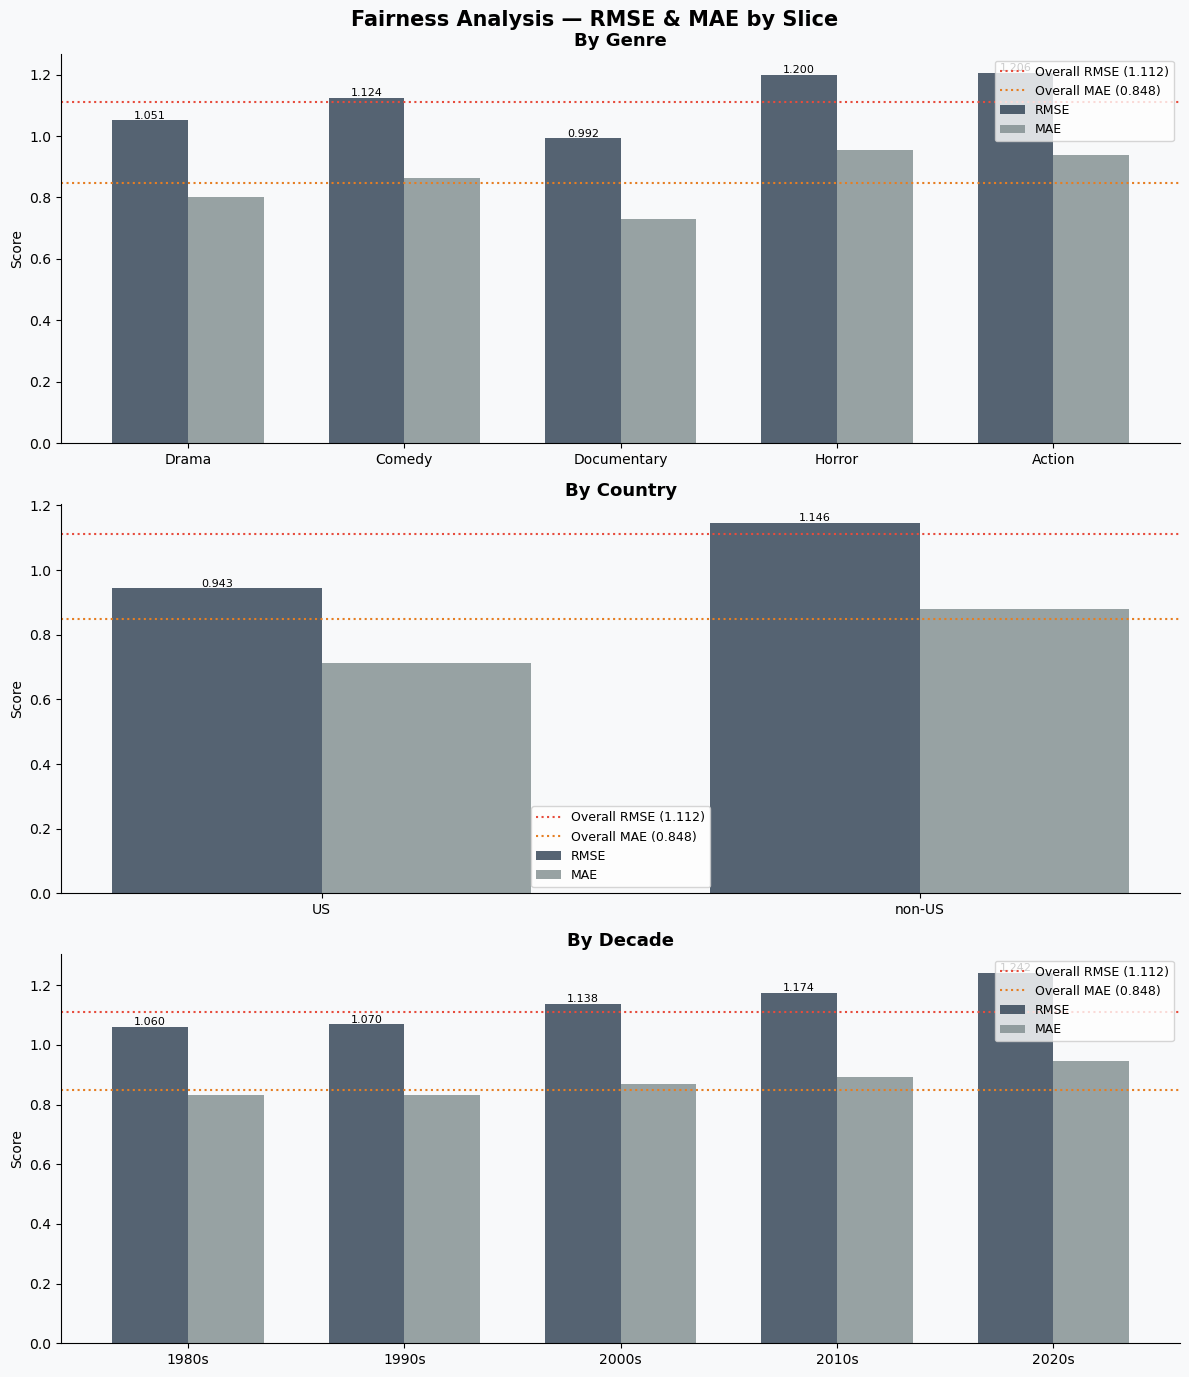

In [47]:
fig, axes = plt.subplots(3, 1, figsize=(12, 14))
fig.patch.set_facecolor('#f8f9fa')

slices = {
    'By Genre'  : fairness_df[fairness_df['Slice'].str.startswith('Genre')],
    'By Country': fairness_df[fairness_df['Slice'].str.startswith('Country')],
    'By Decade' : fairness_df[fairness_df['Slice'].str.startswith('Decade')]
}

for ax, (title, subset) in zip(axes, slices.items()):
    labels = subset['Slice'].str.replace('Genre: |Country: |Decade: ', '', regex=True)
    
    x = range(len(labels))
    width = 0.35
    
    bars1 = ax.bar([i - width/2 for i in x], subset['RMSE'],
                   width, label='RMSE', color='#2c3e50', alpha=0.8)
    bars2 = ax.bar([i + width/2 for i in x], subset['MAE'],
                   width, label='MAE', color='#7f8c8d', alpha=0.8)
    
    ax.axhline(overall_rmse, color='#e74c3c', lw=1.5,
               linestyle=':', label=f'Overall RMSE ({overall_rmse:.3f})')
    ax.axhline(overall_mae, color='#e67e22', lw=1.5,
               linestyle=':', label=f'Overall MAE ({overall_mae:.3f})')
    
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_ylabel('Score')
    ax.legend(fontsize=9)
    ax.set_facecolor('#f8f9fa')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for bar, val in zip(bars1, subset['RMSE']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=8)

plt.suptitle('Fairness Analysis — RMSE & MAE by Slice',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

<div dir="rtl">

## 6.3 דיון

**האם יש חתכים בהם המודל משמעותית פחות מדויק? בכמה באחוזים ביחס לממוצע?**

כן. החתכים הבולטים ביותר:
- Horror: +8.0% מהממוצע
- Action: +8.5% מהממוצע
- non-US: +3.1% מהממוצע
- 2020s: +11.7% מהממוצע

לעומת זאת, Documentary טוב ב-10.7% ו-US טוב ב-15.1% מהממוצע.

**האם יש הסבר למה?**

- Horror ו-Action — דאטא רועש: ז'אנרים הטרוגניים עם B-movies לצד קלאסיקות.
- non-US — פחות דאטא: רוב הסרטים במאגר אמריקאיים, לכן המודל מכיר פחות תבניות של סרטים לא אמריקאיים.
- 2020s — פחות דאטא: סרטים חדשים עם מעט דירוגים, לא יציבים.
- Documentary — דאטא אחיד: קהל ספציפי ומחויב עם דפוסי דירוג עקביים.

**האם זה מעלה חששות לגבי שימוש במודל בפועל? על אילו סרטים לא הייתם סומכים על נויזוי?ו**

כן. לא הייתי סומכת על החיזוי עבור:
- סרטי **Horror ו-Action** — שגיאה גבוהה ב-8-8.5% מהממוצע, דפוסי דירוג לא עקביים.
- סרטים **לא אמריקאיים** — המודל נחשף למעט דוגמאות מקבוצה זו באימון.
- סרטים שיצאו **אחרי 2020** — מעט דירוגים, לא יציבים, שגיאה גבוהה ב-11.7%.
- סרטי **Horror מזרח אסיאתיים** — שילוב של שני חתכים חלשים: Horror + non-US.

עבור **Documentary ו-Drama** — המודל אמין יחסית.

**האם חלוקות חסרי-נתונים (missingness) עשויות להיות מנבאות? האם הן משתלבות עם bias מסוים?**

כן. סרטים עם מידע חסר על מדינה ושפה נוטים להיות non-US — אותה קבוצה שהמודל פחות מדויק עליה. כלומר, חוסר מידע עצמו הוא סימן אזהרה לחיזוי פחות אמין, ומשתלב עם bias כלפי סרטים לא מערביים.

</div>

<div dir="rtl">

## 7. ניתוח חשיבות הפיצרים

In [50]:
# ===========================
# Feature Importance — שני המודלים
# ===========================

# ElasticNet — מקדמים סטנדרטיים
en_model        = best_en.named_steps['model']
en_preprocessor = best_en.named_steps['preprocessor']

feature_names = (
    numerical_cols +
    binary_cols +
    list(en_preprocessor.named_transformers_['cat']
         .named_steps['encoder'].get_feature_names_out(categorical_cols))
)

en_coefs      = en_model.coef_
en_importance = pd.Series(np.abs(en_coefs), index=feature_names)
en_direction  = pd.Series(np.sign(en_coefs), index=feature_names)
top5_en       = en_importance.nlargest(5)

print("Top 5 — ElasticNet:")
for feat in top5_en.index:
    direction = '+' if en_direction[feat] > 0 else '-'
    print(f"  ({direction}) {feat}: {top5_en[feat]:.4f}")

# Random Forest — MDI importance
rf_model      = best_rf.named_steps['model']
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
)
top5_rf = rf_importance.nlargest(5)

# כיוון ל-RF לפי קורלציה עם y_train
print("\nTop 5 — Random Forest:")
for feat in top5_rf.index:
    if feat in X_train.columns:
        corr = X_train[feat].corr(y_train)
        direction = '+' if corr > 0 else '-'
        print(f"  ({direction}) {feat}: {top5_rf[feat]:.4f} | corr={corr:.3f}")


Top 5 — ElasticNet:
  (+) genre_Documentary: 1.3736
  (-) genre_Horror: 0.9051
  (-) genre_Action: 0.4251
  (+) is_east_asian: 0.3648
  (+) genre_Drama: 0.2841

Top 5 — Random Forest:
  (+) genre_Documentary: 0.2493 | corr=0.298
  (-) genre_Horror: 0.1692 | corr=-0.276
  (+) movie_age: 0.1320 | corr=0.032
  (+) runtimeMinutes: 0.1152 | corr=0.156
  (+) runtime_per_genre: 0.0709 | corr=0.101


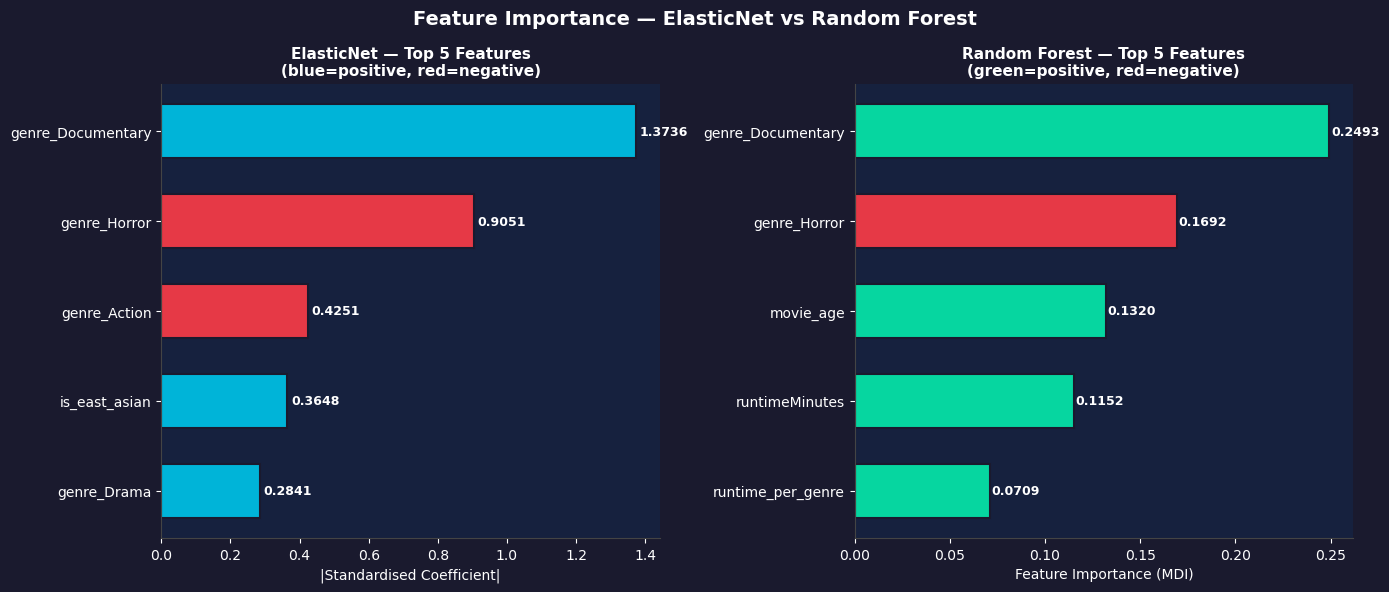

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#1a1a2e')

# ElasticNet
ax = axes[0]
ax.set_facecolor('#16213e')

colors_en = ['#00b4d8' if en_direction[f] > 0 else '#e63946'
             for f in top5_en.index]

bars = ax.barh(top5_en.index[::-1], top5_en.values[::-1],
               color=colors_en[::-1], edgecolor='#1a1a2e',
               linewidth=1.5, height=0.6)

for bar, val in zip(bars, top5_en.values[::-1]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9,
            color='white', fontweight='bold')

ax.set_title('ElasticNet — Top 5 Features\n(blue=positive, red=negative)',
             fontweight='bold', color='white', fontsize=11)
ax.set_xlabel('|Standardised Coefficient|', color='white')
ax.tick_params(colors='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#444')
ax.spines['bottom'].set_color('#444')

# Random Forest
ax = axes[1]
ax.set_facecolor('#16213e')

rf_colors = []
for feat in top5_rf.index:
    if feat in X_train.columns:
        corr = X_train[feat].corr(y_train)
        rf_colors.append('#06d6a0' if corr > 0 else '#e63946')
    else:
        rf_colors.append('#adb5bd')

bars = ax.barh(top5_rf.index[::-1], top5_rf.values[::-1],
               color=rf_colors[::-1], edgecolor='#1a1a2e',
               linewidth=1.5, height=0.6)

for bar, val in zip(bars, top5_rf.values[::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9,
            color='white', fontweight='bold')

ax.set_title('Random Forest — Top 5 Features\n(green=positive, red=negative)',
             fontweight='bold', color='white', fontsize=11)
ax.set_xlabel('Feature Importance (MDI)', color='white')
ax.tick_params(colors='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#444')
ax.spines['bottom'].set_color('#444')

plt.suptitle('Feature Importance — ElasticNet vs Random Forest',
             fontsize=14, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

<div dir="rtl">


### ElasticNet — Top 5

| פיצ'ר | כיוון | משמעות |
|-------|-------|---------|
| genre_Documentary | + | הפיצ'ר החזק ביותר — Documentary מעלה דירוג משמעותית |
| genre_Horror | - | מוריד דירוג בחוזקה — Horror נמוך בעקביות |
| genre_Action | - | מוריד דירוג — Action מתחת לממוצע |
| is_east_asian | + | קולנוע מזרח אסייתי מעלה דירוג — קהל מחויב |
| genre_Drama | + | מעלה דירוג מעט — הז'אנר הנפוץ ביותר |

### Random Forest — Top 5

| פיצ'ר | כיוון | משמעות |
|-------|-------|---------|
| genre_Documentary | + | הכי חשוב גם כאן — עקבי בין המודלים |
| genre_Horror | - | שני בחשיבות — עקבי בין המודלים |
| movie_age | + | RF תופס Survivorship Bias — ElasticNet לא יכול |
| runtimeMinutes | + | סרטים ארוכים מדורגים גבוה — קשר לא-לינארי |
| runtime_per_genre | + | הפיצ'ר המורכב שלנו — מופיע ב-Top 5 |

### השוואה בין המודלים

**היכן הם מסכימים:**
שניהם מסכימים ש-genre_Documentary ו-genre_Horror הם הפרדיקטורים החזקים ביותר — עם אותו כיוון.

**היכן הם מתפצלים:**
movie_age ו-runtimeMinutes חשובים ל-RF אבל לא מופיעים ב-ElasticNet.
הסיבה: הקשר בין גיל וזמן ריצה לדירוג הוא לא-לינארי — RF יכול לתפוס אותו, ElasticNet לא.

is_east_asian חשוב ל-ElasticNet אבל לא ל-RF.
הסיבה: ElasticNet רואה קשר לינארי ישיר — RF מפצל את המידע הזה בין פיצ'רים אחרים.

</div>

<div dir="rtl">

## הערכה על - Held-Out test set

In [54]:
# ===========================
# Final Evaluation on Test Set
# ===========================
print('Final Evaluation on Test Set')
print('=' * 40)

for pipeline, name in [
    (best_rf, 'Random Forest'),
    (best_en, 'ElasticNet'),
]:
    y_pred_test = pipeline.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae  = mean_absolute_error(y_test, y_pred_test)
    r2   = r2_score(y_test, y_pred_test)
    print(f'{name}: RMSE={rmse:.4f} | MAE={mae:.4f} | R²={r2:.4f}')

# ===========================
# שמירת ElasticNet — לפי דרישת המרצה
# ===========================
joblib.dump(best_en, 'model.pkl')
print('\nModel saved: model.pkl (ElasticNet)')

# ===========================
# בדיקה לפי קוד המרצה
# ===========================
df_test       = pd.read_csv('dataset.csv', low_memory=False)
y_check       = df_test['averageRating']
X_check       = prepare_data(df_test)

loaded_model  = joblib.load('model.pkl')
y_pred_check  = loaded_model.predict(X_check)

# מדדים רק על שורות עם דירוג
valid_mask = y_check.notna()
rmse_check = np.sqrt(mean_squared_error(
    y_check[valid_mask], y_pred_check[valid_mask]))
print(f'\nבדיקת תאימות לקוד המרצה:')
print(f'RMSE: {rmse_check:.4f}')
print(f'מספר תחזיות: {len(y_pred_check)}')
print(f'תחזיות לדוגמה: {y_pred_check[:3].round(2)}')

Final Evaluation on Test Set
Random Forest: RMSE=1.1100 | MAE=0.8468 | R²=0.2558
ElasticNet: RMSE=1.1347 | MAE=0.8701 | R²=0.2224

Model saved: model.pkl (ElasticNet)

בדיקת תאימות לקוד המרצה:
RMSE: 1.1381
מספר תחזיות: 133884
תחזיות לדוגמה: [5.96 5.88 5.9 ]
